# Predicting Residential Rental Prices in Rio de Janeiro: A Time Series Analysis

## 1.	Introduction
Rental housing costs have become an increasingly discussed topic in large Brazilian cities, particularly in touristic urban areas, where rental prices have shown a noticeable upward trend over the past decade.

This project analyzes the evolution of residential rental prices in Rio de Janeiro using a long-term time series dataset covering approximately 15 years of data. The goal is to understand historical price behavior, and assess whether rental values can be reasonably forecast using time series methods.

The motivation for this analysis is grounded in personal experience. Having lived in Rio de Janeiro, the perception of continuously rising rents, often associated with neighborhood changes, tourism pressure, and the growth of short-term rental platforms, became increasingly evident. This project aims to move beyond perception and investigate these patterns through a data-driven approach.

By combining **exploratory data analysis and time series modeling**, this study seeks to provide insights into how rental prices evolved over time and how historical patterns can be used to generate forward-looking projections.


##2. Data Collection & Dataset Overview
### 2.1. Data Source & Collection Process
The data used in this project comes from the
[FipeZAP Index](https://www.fipezap.com.br), an o**fficial real estate price indicator** that tracks residential real estate prices in Brazil. The index is produced by the Fundação Instituto de Pesquisas Econômicas (FIPE).

For this analysis, the data was downloaded in Excel format. During the initial preparation stage, the dataset was filtered to include:

* Only **residential rental
properties**, excluding commercial listings.

* Only the **city of Rio de Janeiro**, excluding other Brazilian cities.

* **Monthly observation**, covering the period January 2010 to December 2024, totaling 15 full years of rental price data.

Only the variables relevant to the objectives of this project were retained, allowing for a cleaner and more consistent dataset after the initial filtering process.


## 2.2. Data Scope and Assumptions

* This project focuses on **long-term residential rental price dynamics** in Rio de Janeiro rather than short-term market fluctuations.

* The dataset reflects **aggregated rental price indicators** designed to capture broad market behavior. Neighborhood-level characteristics, individual property conditions, and informal rental agreements are not explicitly modeled and may contribute to unexplained variability.


* External factors, including economic cycles, inflation, public policy changes, and the **expansion of short-term rental platforms such as Airbnb**, may indirectly affect rental prices. These factors are not directly encoded as standalone features in the dataset, but are treated as contextual drivers and discussed qualitatively throughout the analysis.


## 3. Data Preparation & Cleaning

### 3.1. Import Libraries
This project relies on standard Python libraries commonly used for data manipulation, numerical analysis and visualization. These tools provide the foundation for loading, cleaning, and exploring the dataset in the following sections.


In [291]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

### 3.2. Dataset Loading & Initial Inspection

The dataset was originally downloaded in Excel format from the FipeZAP portal and loaded directly into a Pandas DataFrame for analysis.

As the original spreadsheet contains merged headers and hierarchical column names, a preliminary adjustment was required to obtain a clean tabular structure suitable for analysis.

In [292]:
from google.colab import drive
drive.mount('/content/drive')

excel_path = "/content/drive/MyDrive/Colab Notebooks/9. RJ Rental/RJ Rental2.xlsx"

df = pd.read_excel(excel_path,skiprows=3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


After loading the data, an initial inspection is performed to verify the structure, data types, and potential formatting issues inherited from the original Excel file.

In [293]:
df.head().round(2)

,Data,Total,1D,2D,3D,4D,Total.1,1D.1,2D.1,3D.1,...,Total.3,1D.3,2D.3,3D.3,4D.3,Total.4,1D.4,2D.4,3D.4,4D.4
0,2010-01-01,91.03,89.73,91.69,89.78,96.19,0.01,-0.01,-0.00,0.03,...,21.46,23.57,19.22,21.32,29.21,0.0,0.00,0.0,0.00,0.01
1,2010-02-01,92.95,92.86,91.94,93.05,96.90,0.02,0.03,0.00,0.04,...,21.91,24.39,19.27,22.10,29.43,0.0,0.00,0.0,0.01,0.00
2,2010-03-01,95.74,97.96,94.28,94.59,97.80,0.03,0.05,0.03,0.02,...,22.57,25.73,19.76,22.46,29.70,0.0,0.00,0.0,0.00,0.00
3,2010-04-01,97.94,102.58,96.25,95.31,97.45,0.02,0.05,0.02,0.01,...,23.09,26.94,20.18,22.63,29.60,0.0,0.01,0.0,0.00,0.00
4,2010-05-01,98.92,102.25,98.74,95.36,99.44,0.01,-0.00,0.03,0.00,...,23.32,26.85,20.70,22.64,30.20,0.0,0.00,0.0,0.00,0.00


In [294]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 26 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Data     192 non-null    datetime64[ns]
 1   Total    192 non-null    float64       
 2   1D       192 non-null    float64       
 3   2D       192 non-null    float64       
 4   3D       192 non-null    float64       
 5   4D       192 non-null    float64       
 6   Total.1  192 non-null    float64       
 7   1D.1     192 non-null    float64       
 8   2D.1     192 non-null    float64       
 9   3D.1     192 non-null    float64       
 10  4D.1     192 non-null    float64       
 11  Total.2  192 non-null    float64       
 12  1D.2     192 non-null    float64       
 13  2D.2     192 non-null    float64       
 14  3D.2     192 non-null    float64       
 15  4D.2     192 non-null    float64       
 16  Total.3  192 non-null    float64       
 17  1D.3     192 non-null    float64   

The initial inspection confirms a dataset with **192 monthly observations** and no missing values.

The ambiguous and repetitive column names (e.g. `Total`, `Total.1`, `Total.3`) reflect the hierarchical structure of the original Excel file, from which upper header rows were removed during loading. This issue is addressed in the next step through explicit column selection and renaming.



### 3.3. Data Cleaning Strategy

Before moving into exploratory analysis, a small set of essential cleaning steps is applied to ensure that the dataset is suitable for time series analysis and modeling.

The main cleaning decisions at this stage include:




1.   **Column selection**: Due to the hierarchical structure of the original Excel file, the imported dataset contains multiple groups of similarly named columns like `1D` and `1D.1`. Only the columns corresponding to the **rental price index (R$/m²)** are retained, as they directly reflect rental market dynamics. Auxiliary indicators not used in the modeling phase are excluded.
2.   **Column renaming**: The selected variables are renamed to explicitly represent property typology (total, 1-bedroom to 4-bedroom units), resulting in a column structure suitable for analysis.

3. **Date parsing**: The date column is converted to a proper `datetime` format to ensure correct chronological ordering and enable time-based operations.

4. **Consistency checks**: The dataset is inspected for missing values, duplicated rows, and continuity of the monthly time index. No structural inconsistencies were identified at this stage.

In [295]:
# Column selection
df = df.iloc[:, [0, 16,17,18,19,20, 6,7,8,9,10, 11,12,13,14,15]]

# Column renaming
df.columns = ['Date','Rent_Price_Total', 'Rent_Price_1D', 'Rent_Price_2D', 'Rent_Price_3D', 'Rent_Price_4D','Var_Monthly_Total', 'Var_Monthly_1D', 'Var_Monthly_2D', 'Var_Monthly_3D', 'Var_Monthly_4D','Var_12mo_Total', 'Var_12mo_1D', 'Var_12mo_2D', 'Var_12mo_3D', 'Var_12mo_4D']

# Date parsing
df["Date"] = pd.to_datetime(df["Date"])

# Consistency checks
for col in df.columns[6:]:
    df[col] = df[col].astype(str).str.replace('%','').str.replace('+','').astype(float)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               192 non-null    datetime64[ns]
 1   Rent_Price_Total   192 non-null    float64       
 2   Rent_Price_1D      192 non-null    float64       
 3   Rent_Price_2D      192 non-null    float64       
 4   Rent_Price_3D      192 non-null    float64       
 5   Rent_Price_4D      192 non-null    float64       
 6   Var_Monthly_Total  192 non-null    float64       
 7   Var_Monthly_1D     192 non-null    float64       
 8   Var_Monthly_2D     192 non-null    float64       
 9   Var_Monthly_3D     192 non-null    float64       
 10  Var_Monthly_4D     192 non-null    float64       
 11  Var_12mo_Total     192 non-null    float64       
 12  Var_12mo_1D        192 non-null    float64       
 13  Var_12mo_2D        192 non-null    float64       
 14  Var_12mo_3

These steps ensure that the dataset is clean, consistent, and ready for exploratory analysis and forecasting.

## 4. Exploratory Data Analysis

### 4.1. Long-Term Rental Price Trends

Here we analyze the historical evolution of **rental prices in Rio de Janeiro** over the past 15 years. This helps to understand the big picture before diving into more detailed analysis.

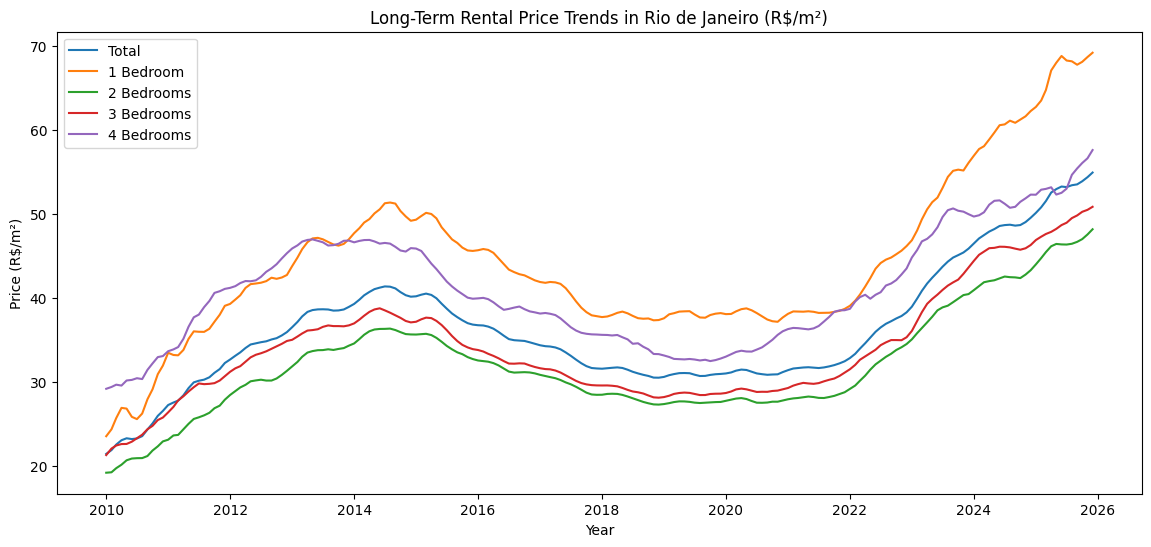

In [296]:
plt.figure(figsize=(14,6))
sns.lineplot(data=df, x='Date', y='Rent_Price_Total', label='Total')
sns.lineplot(data=df, x='Date', y='Rent_Price_1D', label='1 Bedroom')
sns.lineplot(data=df, x='Date', y='Rent_Price_2D', label='2 Bedrooms')
sns.lineplot(data=df, x='Date', y='Rent_Price_3D', label='3 Bedrooms')
sns.lineplot(data=df, x='Date', y='Rent_Price_4D', label='4 Bedrooms')

plt.title('Long-Term Rental Price Trends in Rio de Janeiro (R$/m²)')
plt.xlabel('Year')
plt.ylabel('Price (R$/m²)')
plt.legend()
plt.show()


**Insights**:

* Rental prices show a clear and persistent **upward trend** over the 15-year period.

* Periods of acceleration and slowdown are visible, reflecting macroeconomic events such as economic crises and the COVID-19 pandemic.

* While all property types follow similar long-term trajectories, price levels differ across unit sizes.


### 4.2. Price Evolution by Property Typology


To better understand market heterogeneity, rental prices are analyzed by **property typology** (Total, 1-bedroom, 2-bedroom, 3-bedroom, and 4-bedroom units).

This provides a clearer view of which apartment sizes experienced faster price growth.



In [297]:
start_prices = df.loc[df['Date'].dt.year == 2010, ['Rent_Price_Total','Rent_Price_1D','Rent_Price_2D','Rent_Price_3D','Rent_Price_4D']].mean()
end_prices = df.loc[df['Date'].dt.year == 2024, ['Rent_Price_Total','Rent_Price_1D','Rent_Price_2D','Rent_Price_3D','Rent_Price_4D']].mean()

price_growth = (end_prices - start_prices) / start_prices * 100
price_growth.name = 'Price Growth (%)'
price_growth.round(2)


,Price Growth (%)
Rent_Price_Total,103.64
Rent_Price_1D,121.33
Rent_Price_2D,102.49
Rent_Price_3D,95.05
Rent_Price_4D,66.04


**Insights**:

* **1-bedroom units exhibit the highest rental prices** per square meter, reflecting strong demand for smaller units in urban and touristic areas.

* 2- and 3-bedroom units follow similar trajectories, though with slightly lower price levels.

* 4-bedroom units show lower price growth per square meter, suggesting different demand dynamics compared to smaller units.


Despite differences in price levels and growth rates, all typologies follow **similar long-term trends**, suggesting that broader macroeconomic and structural factors shape rental price dynamics across the market rather than affecting specific unit sizes in isolation.

### 4.3. Monthly and Annual Price Variations

This section explores **short-term and long-term rental price movements** using monthly and annual variation metrics. The objective is to assess volatility patterns and understand which time scale better captures rental market dynamics.

First, monthly rental price variations are examined through basic descriptive statistics.

In [298]:
df[['Var_Monthly_Total', 'Var_12mo_Total']].describe()

,Var_Monthly_Total,Var_12mo_Total
count,192.000000,192.000000
mean,0.004989,0.070019
std,0.010159,0.107484
min,-0.016311,-0.100203
25%,-0.001768,-0.019570
50%,0.004071,0.070864
75%,0.011644,0.157042
max,0.035912,0.295089


Monthly variations are centered close to zero (≈ 0.5%), indicating **limited short-term volatility**. In contrast, annual variations show a much wider range (from approximately −10% to +30%), capturing **stronger medium-term rental price cycles**.

To better understand long-term dynamics, annual rental price variations are analyzed over time.

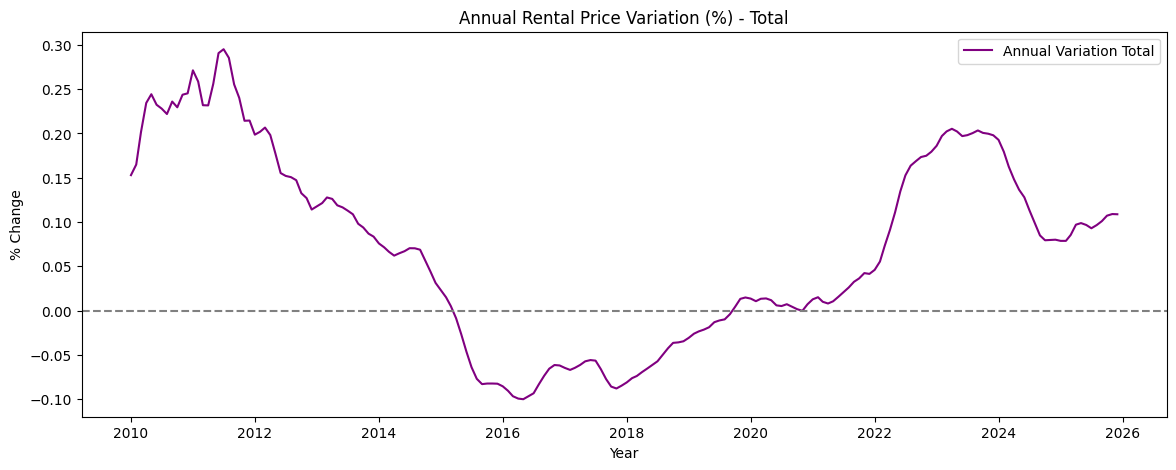

In [299]:
plt.figure(figsize=(14,5))
sns.lineplot(data=df, x='Date', y='Var_12mo_Total', label='Annual Variation Total', color='purple')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Annual Rental Price Variation (%) - Total')
plt.xlabel('Year')
plt.ylabel('% Change')
plt.show()


The annual variation series highlights clear rental price cycles, with strong **growth between 2010 and 2012**, a prolonged contraction from 2015 to 2017, and a **renewed upward trend after 2022**, indicating a post-crisis recovery in the rental market.

Finally, the periods with the highest and lowest annual rental price changes are identified.

In [300]:
row_max = df.loc[df['Var_12mo_Total'].idxmax(),['Date', 'Rent_Price_Total', 'Var_Monthly_Total', 'Var_12mo_Total']]
row_max['Date'] = row_max['Date'].strftime('%b %Y')
print("Month with highest annual rental price growth (Total):")
print(row_max.to_string())

Month with highest annual rental price growth (Total):
Date                  Jul 2011
Rent_Price_Total     30.172498
Var_Monthly_Total     0.006477
Var_12mo_Total        0.295089


In [301]:
row_min = df.loc[df['Var_12mo_Total'].idxmin(),['Date', 'Rent_Price_Total', 'Var_Monthly_Total', 'Var_12mo_Total']]
row_min['Date'] = row_min['Date'].strftime('%b %Y')
print("Month with lowest annual rental price growth (Total):")
print(row_min.to_string())

Month with lowest annual rental price growth (Total):
Date                  May 2016
Rent_Price_Total     35.981344
Var_Monthly_Total    -0.010685
Var_12mo_Total       -0.100203


The strongest annual rental price growth occurred in **July 2011 (+29.5%)**, while the strongest contraction was observed in **May 2016 (−10.0%)**, illustrating periods of rapid expansion followed by market adjustment.




### 4.4. Economic Cycles and Structural Breaks
Several structural patterns emerge when observing the data over longer horizons:

* **2010–2013**: Strong rental price growth, aligned with economic expansion and increased urban demand.

* **2015–2017**: Sustained negative 12-month variations, reflecting Brazil’s economic recession and reduced purchasing power.

* **2020-2021**: Market disruption during the COVID-19 pandemic, followed by a short adjustment period.

* **2022–2024**: Renewed acceleration in rental prices, suggesting recovery and renewed pressure on housing demand. The expansion of short-term rental platforms such as Airbnb is often discussed as a contributing factor to increased rental pressure in large urban and touristic cities like Rio de Janeiro.

These patterns indicate that rental prices are strongly influenced by **macroeconomic cycles**, reinforcing the need for models that capture temporal dependencies.


## 4.5 Key Takeaways
* **Long-term trend**: Rental prices in Rio de Janeiro have **consistently increased**, despite temporary downturns.

* **Property type differences**: Smaller units, especially 1-bedroom apartments, experienced stronger price growth per square meter.


* **Economic sensitivity**: Rental prices respond clearly to macroeconomic shocks, such as the 2015–2016 recession and the COVID-19 period.

These insights provide a **solid foundation for the forecasting section**, offering essential context for predicting future rental price dynamics.


## 5. Modeling and Forecasting

Based on the strong temporal structure identified in the exploratory analysis, this section focuses on forecasting future rental prices in Rio de Janeiro using a time series approach. The objective is to model and project price dynamics driven by historical patterns, without introducing external explanatory variables.

### 5.1 Modeling Approach

Rental prices exhibit clear trends, cycles, and persistence over time, as shown in the EDA. Given these characteristics, a univariate time series model is appropriate to capture temporal dependencies directly from historical observations.

An **ARIMA (AutoRegressive Integrated Moving Average)** model was selected as a baseline forecasting approach due to:

* its suitability for economic and financial time series,

* its ability to handle non-stationary data through differencing,


* and its interpretability, making it a strong reference model for long-term price projections.


## 5.2 ARIMA Model Specification

The model was fitted using monthly rental price data (`Rent_Price_Total`), after applying the necessary transformations to ensure stationarity. Model orders were selected based on standard diagnostics and information criteria (e.g., AIC), following common practices in time series modeling. This approach allows the model to capture:

* short-term autocorrelation patterns,

* medium-term adjustments,

* and long-term price dynamics observed in the historical series.


In [302]:
# Set date as index and target series
df.set_index('Date', inplace=True)
ts = df['Rent_Price_Total']

# Fit ARIMA model
model = ARIMA(ts, order=(1,1,1))
model_fit = model.fit()

model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:       Rent_Price_Total   No. Observations:                  192
Model:                 ARIMA(1, 1, 1)   Log Likelihood                  87.191
Date:                Fri, 23 Jan 2026   AIC                           -168.383
Time:                        16:22:31   BIC                           -158.626
Sample:                    01-01-2010   HQIC                          -164.431
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8943      0.032     28.245      0.000       0.832       0.956
ma.L1          0.1712      0.072      2.371      0.018       0.030       0.313
sigma2         0.0233      0.002     11.547      0.000       0.019       0.027
===================================================================================
Ljung-Box (L1) (Q):                   0.33   Jarque-Bera (JB):                10.13
Prob(Q):                              0.56   Prob(JB):                         0.01
Heteroskedasticity (H):               0.70   Skew:                            -0.17
Prob(H) (two-sided):                  0.16   Kurtosis:                         4.08
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

* The ARIMA(1,1,1) results indicate statistically significant autoregressive and moving average components, suggesting **strong temporal dependence in rental prices**.

* Diagnostic statistics do not indicate severe autocorrelation issues, supporting the adequacy of the chosen specification.


###5.3. Forecast Generation and Visualization

This section presents the visual comparison between historical rental prices and the projected values for the next 24 months.

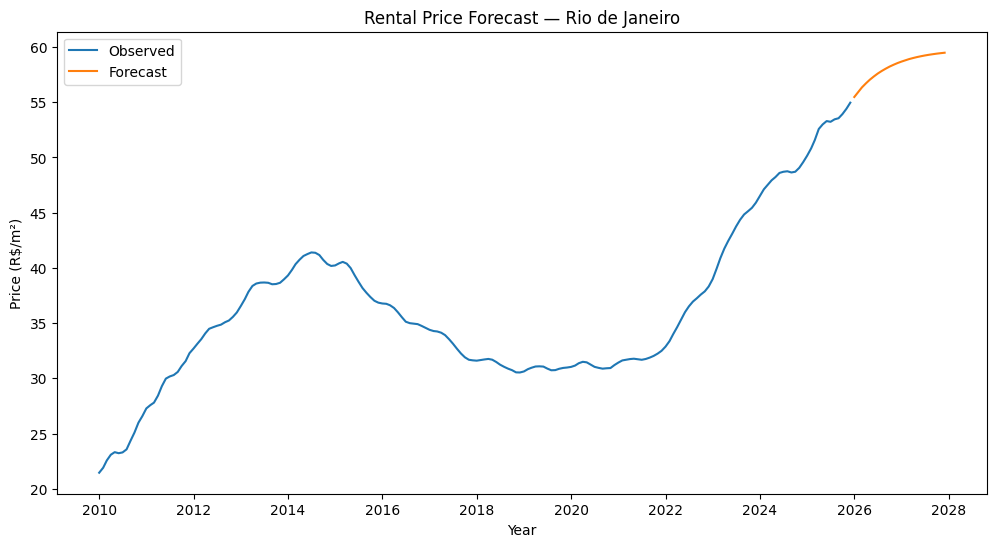

In [303]:
# Forecast next 24 months
forecast = model_fit.forecast(steps=24)

# Plot historical series and forecast
plt.figure(figsize=(12,6))
plt.plot(ts, label='Observed')
plt.plot(forecast, label='Forecast')
plt.title('Rental Price Forecast — Rio de Janeiro')
plt.xlabel('Year')
plt.ylabel('Price (R$/m²)')
plt.legend()
plt.show()

The numerical forecast confirms the visual pattern, indicating a steady month-over-month increase in predicted rental prices throughout 2026 and 2027.

### 5.4. Model Diagnostics and Forecast Interpretation

After fitting the ARIMA model, diagnostic checks are performed to assess whether the residuals behave like white noise, indicating an adequate model specification.

* **Residual behavior**: The residual series shows no visible systematic patterns over time, suggesting that the main temporal structure of the data has been captured.

* **Autocorrelation**: The residual autocorrelation function presents no significant remaining lags, indicating the absence of serial dependence.

* **Overall adequacy**: Together, these diagnostics support the suitability of the ARIMA model for representing the rental price dynamics and for generating short- to medium-term forecasts.

Based on the validated model, the forecast indicates a **gradual and sustained increase in average rental prices**, consistent with the post-2022 recovery observed in the historical data. The projected trajectory reflects the persistence of recent upward trends rather than abrupt structural changes.

As an **univariate time series model**, ARIMA captures temporal patterns effectively but does not incorporate external drivers such as regulatory changes, macroeconomic shocks, or the expansion of short-term rental platforms. Therefore, the forecast should be interpreted as a **trend-based projection**, not as a causal estimate of future rental price movements.


## 6. Conclusion and Key Insights

This project does not assess whether higher or lower prices are desirable, it provides a **data-driven description of how rental prices in Rio de Janeiro have evolved over time**, offering insights relevant to real estate analysis, urban economics, and policy discussions.

* The forecast suggests that **rental prices are expected to continue increasing** in the next two years, following the historical upward trend.

* The COVID-19 pandemic (2020–2021) represents a clear structural disruption in the time series, followed by a period of recovery and renewed growth in rental prices.

* Smaller units, particularly 1-bedroom apartments, consistently exhibit higher prices per square meter, reflecting persistent demand pressures in dense and highly urbanized areas.


* While short-term fluctuations are evident and may reflect broader economic conditions, the **dominant long-term trajectory remains upward**, indicating sustained pressure on rental prices.

* In tourist cities such as Rio de Janeiro, **short-term rental platforms (e.g., Airbnb)** are frequently discussed as potential contributors to rental price pressure. Although these factors are not explicitly modeled, the **observed trends are consistent** with broader urban housing dynamics.


## 7. Next Steps

* Extend the analysis by incorporating **macroeconomic indicators** (e.g., inflation, interest rates) to better contextualize long-term rental price dynamics.

* Explore the potential impact of **short-term rental platforms**, such as Airbnb, by comparing official residential rent indices with short-term rental price trends.

* Incorporate **property subtypes** (1D–4D) directly into the forecasting framework.

* Perform a **spatial and temporal analysis by neighborhood**, allowing for the identification of heterogeneous rental dynamics across different areas of Rio de Janeiro.



